# Customer Review Score Classification

## Classification — Part A

### Machine Learning Capstone Project

This notebook covers:

- Dataset loading and auditing
- Exploratory Data Analysis (EDA)
- Data cleaning
- Feature engineering
- Feature selection
- Train-test splitting
- Common preprocessing pipeline

The preprocessed dataset generated here will be used by the
five Classification Part-A algorithm notebooks.

## 1. Problem Statement

The objective of this classification task is to predict the customer
review score associated with an order using relevant information about
the order, product, customer, seller, and purchase.

The target variable is `review_score`, which contains five possible
classes: 1, 2, 3, 4, and 5.

Therefore, this is a multi-class classification problem.

In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [2]:
df = pd.read_csv('dataset.csv')
df

,order_id,customer_id,order_purchase_timestamp,order_status,customer_city,customer_state,product_id,seller_id,price,freight_value,review_score,review_comment_title,review_comment_message,seller_city,seller_state,product_weight_g,product_category_name_english
0,0006ec9db01a64e59a68b2c340bf65a7,5d178120c29c61748ea95bac23cb8f25,2018-07-24 17:04:17,delivered,rio de janeiro,RJ,99a4788cb24856965c36a24e339b6058,4a3ca9315b744ce9f8e9374361493884,74.00,23.32,5.0,Boa,Excelente serviço de compras on line.,ibitinga,SP,1383,bed_bath_table
1,0009c9a17f916a706d71784483a5d643,8a250edc40ebc5c3940ebc940f16a7eb,2018-04-25 09:10:41,delivered,campinas,SP,3f27ac8e699df3d300ec4a5d8c5cf0b2,fcb5ace8bcc92f75707dc0f01a27d269,639.00,11.34,4.0,NaN,NaN,guarulhos,SP,200,consoles_games
2,000aed2e25dbad2f9ddb70584c5a2ded,fff5169e583fd07fac9fec88962f189d,2018-05-11 20:33:38,delivered,santa barbara d'oeste,SP,4fa33915031a8cde03dd0d3e8fb27f01,fe2032dab1a61af8794248c8196565c9,144.00,8.77,NaN,NaN,NaN,campinas,SP,468,perfumery
3,002175704e8b209f61b9ad5cfd92b60e,a562db3c7cb9a68947debd30879b491e,2018-04-22 12:13:25,delivered,araraquara,SP,e6b6e13cf71449a457269f425b89dc74,b2ba3715d723d245138f291a6fe42594,109.90,13.21,4.0,Recomendo,Produto como descrito. Mas não gostei pq o som...,sao paulo,SP,588,audio
4,930fff097a9427c8a9a70559aa36fa76,dc56b538928bb9f7212da239e24cda3d,2018-08-22 11:52:54,delivered,maua,SP,5d6bea33648f018dbb563f3a2fab09f3,1025f0e2d44d7041d6cf58b6550e0bfa,159.80,16.42,2.0,NaN,Produto lindo! De ótima qualidade,sao paulo,SP,4000,furniture_decor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32990,928e8e158d1096bf9bad69d9e927b6b0,925ddf3482c150d9e469c4b47d52e1c2,2018-05-22 20:21:55,delivered,caruaru,PE,332842d24e84234cd91299a225de76ab,634964b17796e64304cadf1ad3050fb7,399.00,59.34,4.0,10,NaN,rio de janeiro,RJ,1750,watches_gifts
32991,92907309dff7adcd19bbbb29d5fda792,5f5babb717b93691c4757d4bfc1293a2,2018-08-18 22:38:03,delivered,sao bernardo do campo,SP,90dbd461e405599ef4d208e19e472125,c3aad7dc65449ae90a5e9c3c6c1e78e0,90.00,17.76,4.0,NaN,NaN,auriflama/sp,SP,4100,party_supplies
32992,92b7ad3b562646f9112aa21df37f790b,c9da69edb9b3c5e7b8074ac4ea9b2244,2018-08-20 19:02:22,delivered,itapema,SC,6f4f2bb136fd2d8e8229355d8fec6b67,06e5eefc71ec47ae763c5c6f8db7064f,379.94,20.76,4.0,Estou configurando nest,NaN,porto alegre,RS,350,construction_tools_safety
32993,92d1d8203d3deb0f8b536250763d8bca,b74f0b9f1edb86da06a9c032d80fd1e8,2018-08-11 16:39:54,delivered,osasco,SP,23cb417be12fb9557a815962aedefff5,bb135baca94c82fcb731335ad5b04a03,45.00,7.58,4.0,NaN,NaN,sao paulo,SP,200,housewares


## Reviewing the dataset

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 32995
Number of columns: 17


In [4]:
print("First 5 rows:")
df.head()

First 5 rows:


,order_id,customer_id,order_purchase_timestamp,order_status,customer_city,customer_state,product_id,seller_id,price,freight_value,review_score,review_comment_title,review_comment_message,seller_city,seller_state,product_weight_g,product_category_name_english
0,0006ec9db01a64e59a68b2c340bf65a7,5d178120c29c61748ea95bac23cb8f25,2018-07-24 17:04:17,delivered,rio de janeiro,RJ,99a4788cb24856965c36a24e339b6058,4a3ca9315b744ce9f8e9374361493884,74.0,23.32,5.0,Boa,Excelente serviço de compras on line.,ibitinga,SP,1383,bed_bath_table
1,0009c9a17f916a706d71784483a5d643,8a250edc40ebc5c3940ebc940f16a7eb,2018-04-25 09:10:41,delivered,campinas,SP,3f27ac8e699df3d300ec4a5d8c5cf0b2,fcb5ace8bcc92f75707dc0f01a27d269,639.0,11.34,4.0,NaN,NaN,guarulhos,SP,200,consoles_games
2,000aed2e25dbad2f9ddb70584c5a2ded,fff5169e583fd07fac9fec88962f189d,2018-05-11 20:33:38,delivered,santa barbara d'oeste,SP,4fa33915031a8cde03dd0d3e8fb27f01,fe2032dab1a61af8794248c8196565c9,144.0,8.77,NaN,NaN,NaN,campinas,SP,468,perfumery
3,002175704e8b209f61b9ad5cfd92b60e,a562db3c7cb9a68947debd30879b491e,2018-04-22 12:13:25,delivered,araraquara,SP,e6b6e13cf71449a457269f425b89dc74,b2ba3715d723d245138f291a6fe42594,109.9,13.21,4.0,Recomendo,Produto como descrito. Mas não gostei pq o som...,sao paulo,SP,588,audio
4,930fff097a9427c8a9a70559aa36fa76,dc56b538928bb9f7212da239e24cda3d,2018-08-22 11:52:54,delivered,maua,SP,5d6bea33648f018dbb563f3a2fab09f3,1025f0e2d44d7041d6cf58b6550e0bfa,159.8,16.42,2.0,NaN,Produto lindo! De ótima qualidade,sao paulo,SP,4000,furniture_decor


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32995 entries, 0 to 32994
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       32995 non-null  object 
 1   customer_id                    32995 non-null  object 
 2   order_purchase_timestamp       32995 non-null  object 
 3   order_status                   32995 non-null  object 
 4   customer_city                  32995 non-null  object 
 5   customer_state                 32995 non-null  object 
 6   product_id                     32995 non-null  object 
 7   seller_id                      32995 non-null  object 
 8   price                          32995 non-null  float64
 9   freight_value                  32995 non-null  float64
 10  review_score                   23435 non-null  float64
 11  review_comment_title           9090 non-null   object 
 12  review_comment_message         9589 non-null  

## Columns split into categories

### Identifiers:
- order_id
- customer_id
- product_id
- seller_id

### Numerical
- price
- freight_value
- review_score
- product_weight_g

### Categorical
- order_status
- customer_city
- customer_state
- seller_city
- seller_state
- product_category_name_english

### Date/time
- order_purchase_timestamp

### Text
- review_comment_title
- review_comment_message

In [7]:
df.describe()

,price,freight_value,review_score,product_weight_g
count,32995.000000,32995.000000,23435.000000,32995.000000
mean,123.072503,21.061500,3.409473,1925.218154
std,194.338391,18.291288,1.301759,3454.403550
min,0.850000,0.000000,1.000000,0.000000
25%,39.990000,12.790000,2.000000,264.000000
50%,77.900000,18.200000,3.000000,600.000000
75%,134.990000,22.980000,5.000000,1683.000000
max,6729.000000,375.280000,5.000000,30000.000000


In [8]:
df.describe(include='object')

,order_id,customer_id,order_purchase_timestamp,order_status,customer_city,customer_state,product_id,seller_id,review_comment_title,review_comment_message,seller_city,seller_state,product_category_name_english
count,32995,32995,32995,32995,32995,32995,32995,32995,9090,9589,32995,32995,32995
unique,28891,28891,28745,5,2521,27,13359,2034,3253,7412,464,19,70
top,af822dacd6f5cff7376413c03a388bb7,9eb3d566e87289dcb0acf28e1407c839,2018-05-13 13:05:02,delivered,sao paulo,SP,53b36df67ebb7c41585e8d54d6772e08,6560211a19b47992c3666cc44a7e94c0,Recomendo,Muito bom,sao paulo,SP,health_beauty
freq,12,12,12,32514,5953,15290,210,772,327,55,8577,23667,3620


In [9]:
missing_df = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_df = missing_df.sort_values(
    by="Missing Count",
    ascending=False
)

missing_df

,Missing Count,Missing Percentage
review_comment_title,23905,72.450371
review_comment_message,23406,70.938021
review_score,9560,28.974087
order_id,0,0.000000
freight_value,0,0.000000
product_weight_g,0,0.000000
seller_state,0,0.000000
seller_city,0,0.000000
price,0,0.000000
customer_id,0,0.000000


In [10]:
duplicate_count = df.duplicated().sum()

print("Number of exact duplicate rows:", duplicate_count)

Number of exact duplicate rows: 2951


In [11]:
print("Unique review scores:")
print(sorted(df["review_score"].dropna().unique()))

Unique review scores:
[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]


In [13]:
target_counts = df["review_score"].value_counts(dropna=False).sort_index()
target_counts

review_score
1.0    2344
2.0    3703
3.0    5688
4.0    5413
5.0    6287
NaN    9560
Name: count, dtype: int64

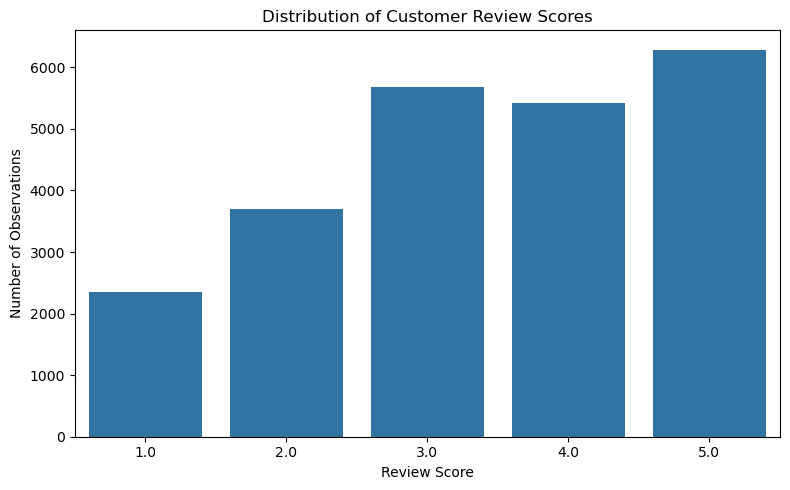

In [14]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="review_score"
)

plt.title("Distribution of Customer Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Number of Observations")

plt.tight_layout()
plt.show()

### Observation

The target variable contains five review-score classes ranging from 1
to 5. The class frequencies are not equal, with higher review scores
being more frequent than the lower scores. In addition, a substantial
number of observations do not have a recorded review score and will
therefore require separate handling before supervised model training.

## 2. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distributions,
relationships, patterns, and potential anomalies present in the dataset
before applying data preprocessing and classification algorithms./

### 2.1 Numerical Feature Analysis

From our dataset, the main numerical predictor variables are:
- price
- freight_value
- product_weight_g

In [18]:
numerical_features = [
    "price",
    "freight_value",
    "product_weight_g"
]

print("The numerical features are:", numerical_features)

The numerical features are: ['price', 'freight_value', 'product_weight_g']


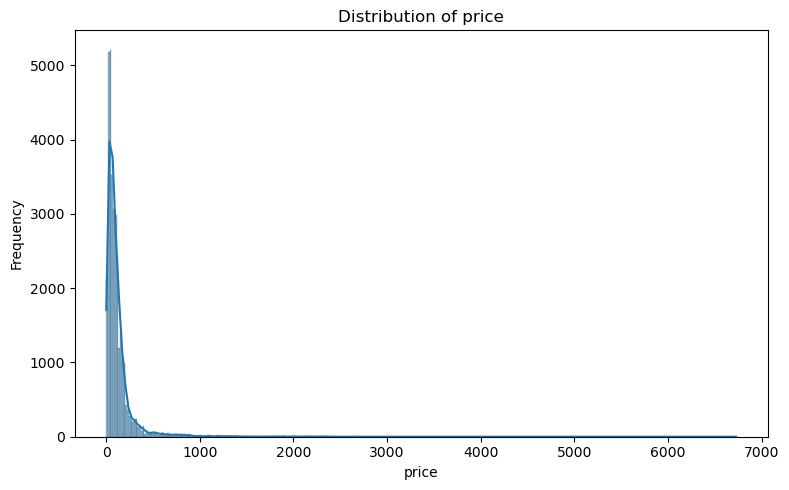

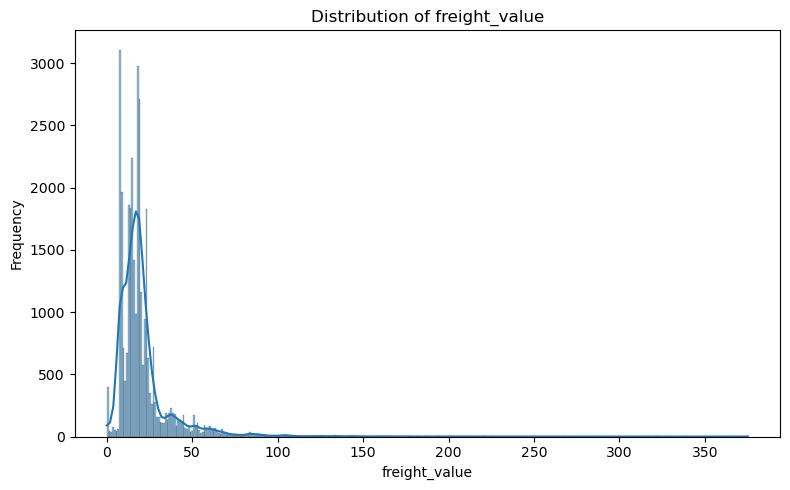

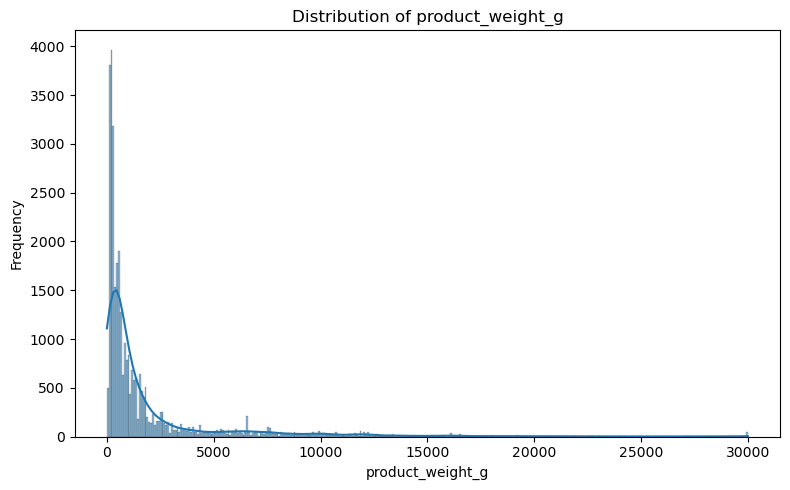

In [19]:
for feature in numerical_features:
    plt.figure(figsize=(8, 5))
    
    sns.histplot(
        data=df,
        x=feature,
        kde=True
    )
    
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()

#### Observation
- `price`: The price distribution is highly right-skewed, with most products concentrated in the lower price range and a small number of products having substantially higher prices. This indicates the presence of extreme values in the price feature.

- `freight_value`: The freight value distribution is right-skewed, with most observations concentrated at lower shipping costs and fewer observations having high freight charges. These extreme values should be examined during outlier analysis.

- `product_weight_g`: The product weight distribution is highly right-skewed. Most products have relatively low weights, while a smaller number of products have substantially higher weights, resulting in a long right tail and potential outliers.

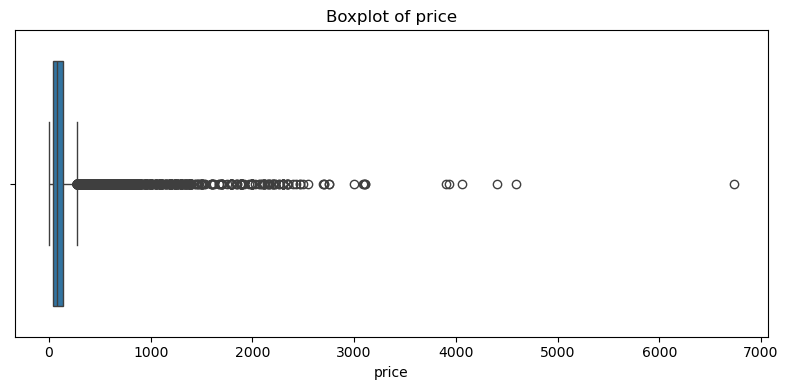

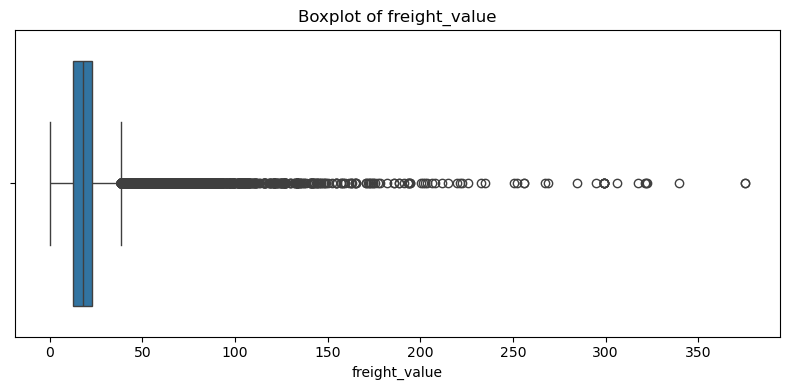

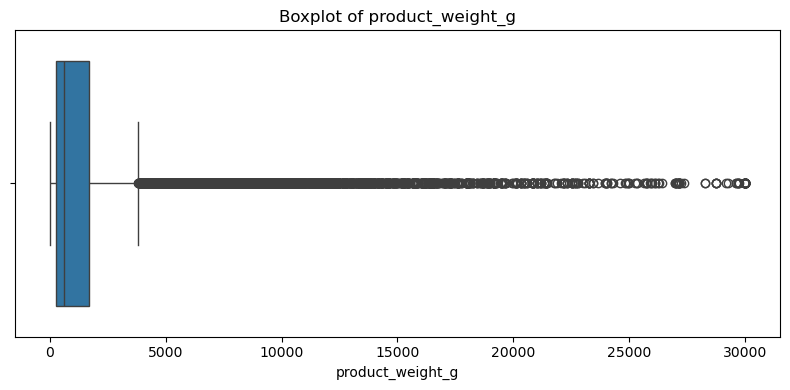

In [20]:
for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(
        data=df,
        x=feature
    )
    
    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)
    
    plt.tight_layout()
    plt.show()

#### Observation
- `price`: The boxplot shows that most price values are concentrated in a relatively small range, while a large number of observations extend beyond the upper whisker. This indicates a strong right skew and the presence of numerous high-price outliers.

- `freight_value`: The freight value boxplot shows that most observations are concentrated at lower freight values, with many observations beyond the upper whisker. This indicates right skewness and the presence of high freight-value outliers.

- `product_weight_g`: The product weight boxplot shows a relatively compact central range with numerous observations extending far beyond the upper whisker. This indicates strong right skewness and several potentially extreme product weights.

### Correlation Analysis

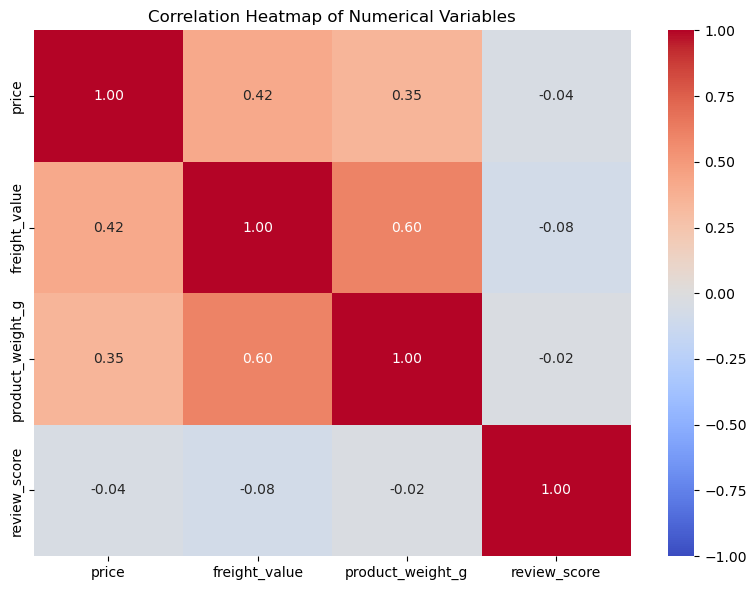

In [22]:
corr_features = [
    "price",
    "freight_value",
    "product_weight_g",
    "review_score"
]

corr_matrix = df[corr_features].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

#### Observation:
The numerical features show varying degrees of correlation with each other. 
Freight value and product weight have the strongest positive correlation (0.60), while 
price has moderate positive correlations with freight value (0.42) and product weight (0.35). 
In contrast, all three numerical features have very weak linear correlations with the 
review score, with correlation values close to zero. This suggests that these numerical 
features alone may have limited linear association with the review score.

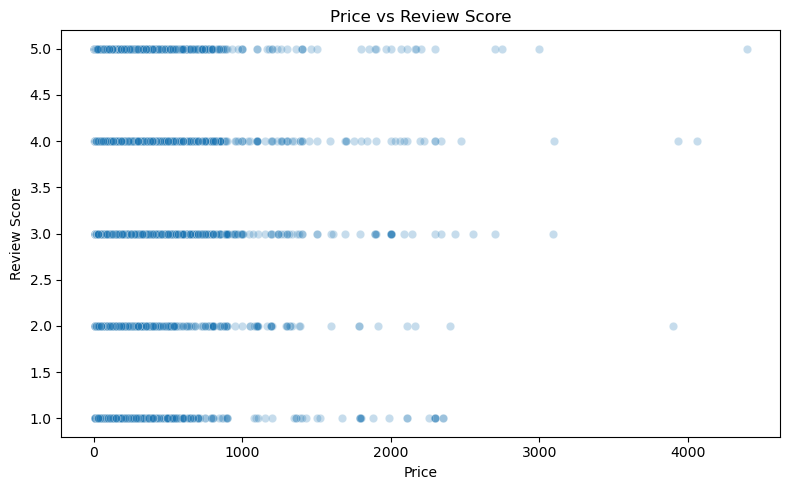

In [23]:
plot_df = df.dropna(subset=["review_score"])

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=plot_df,
    x="price",
    y="review_score",
    alpha=0.25
)

plt.title("Price vs Review Score")
plt.xlabel("Price")
plt.ylabel("Review Score")
plt.tight_layout()
plt.show()

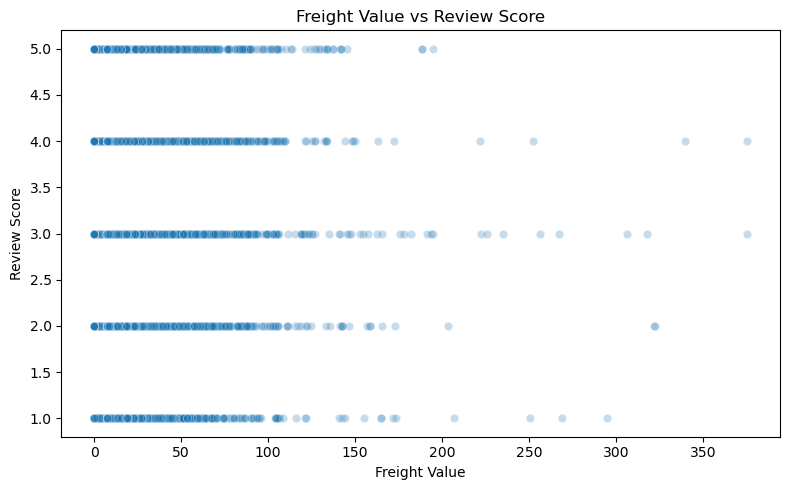

In [24]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=plot_df,
    x="freight_value",
    y="review_score",
    alpha=0.25
)

plt.title("Freight Value vs Review Score")
plt.xlabel("Freight Value")
plt.ylabel("Review Score")
plt.tight_layout()
plt.show()

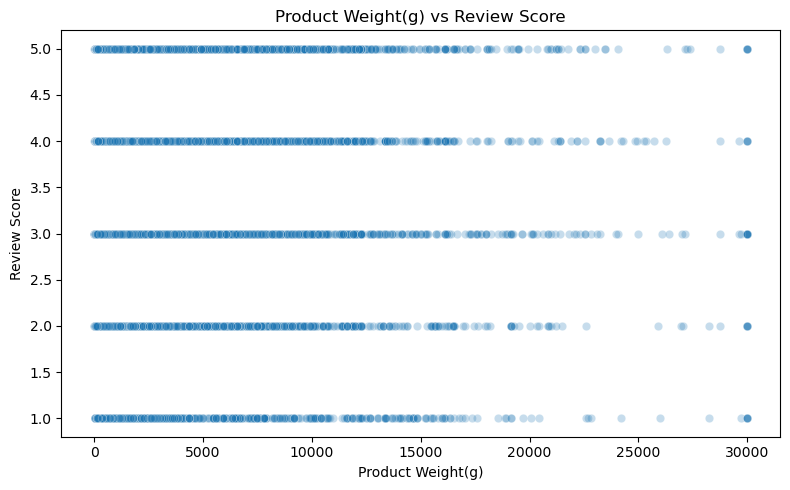

In [25]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=plot_df,
    x="product_weight_g",
    y="review_score",
    alpha=0.25
)

plt.title("Product Weight(g) vs Review Score")
plt.xlabel("Product Weight(g)")
plt.ylabel("Review Score")
plt.tight_layout()
plt.show()

### Observation: 

- `price`: The scatter plot shows that all review score categories occur across a wide range of prices, with most observations concentrated at lower prices. No clear linear trend between price and review score is visible, which is consistent with the very weak correlation (-0.04) observed in the correlation heatmap.

- `freight_values`: The scatter plot shows that all review score categories are distributed across the common range of freight values. No strong linear relationship between freight value and review score is apparent. This is consistent with the very weak negative correlation (-0.08) observed in the correlation heatmap.

- `product_weight_g`: The scatter plot shows that all review score categories occur across a wide range of product weights, with most observations concentrated at lower weights. No clear linear relationship between product weight and review score is visible. This is consistent with the very weak correlation (-0.02) observed in the correlation heatmap.

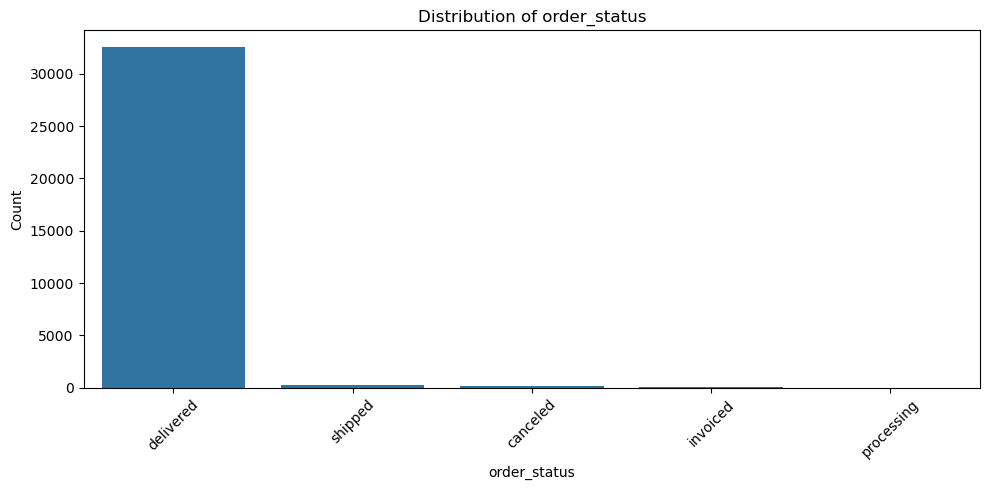

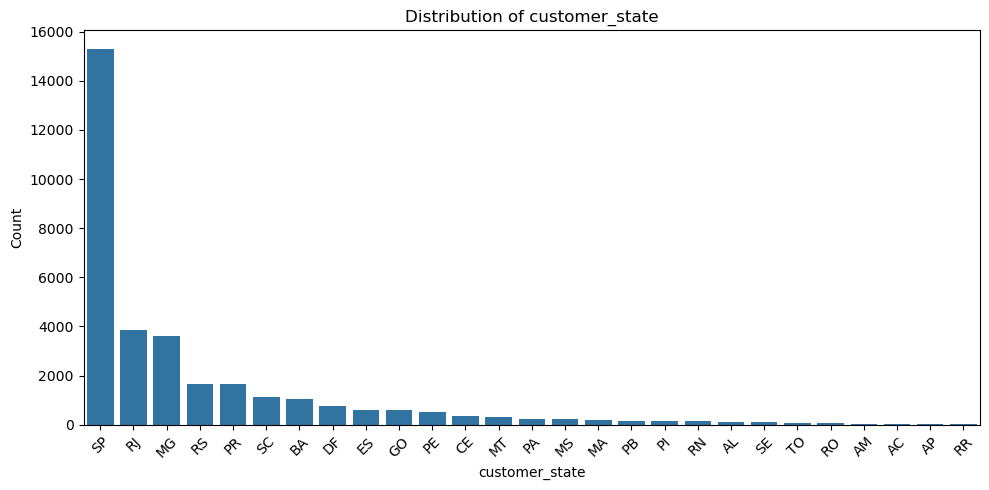

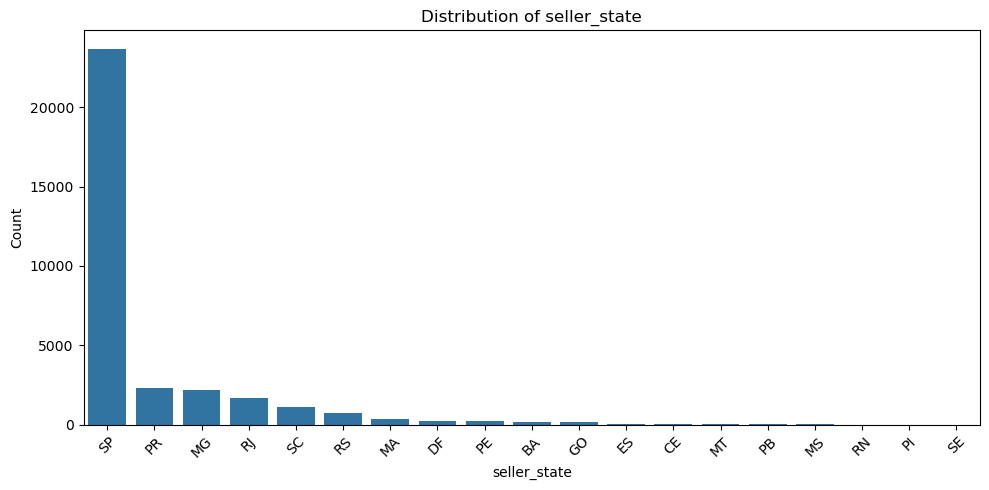

In [26]:
categorical_features = [
    "order_status",
    "customer_state",
    "seller_state"
]

for feature in categorical_features:
    plt.figure(figsize=(10, 5))
    
    sns.countplot(
        data=df,
        x=feature,
        order=df[feature].value_counts().index
    )
    
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Observation: 

- `order_status`: The order status distribution is highly imbalanced, with the vast majority of orders having a "delivered" status. The remaining categories such as "shipped", "canceled", "invoiced", and "processing" occur much less frequently.

- `customer_state`: The customer state distribution is imbalanced, with São Paulo (SP) accounting for the largest share of observations, followed by Rio de Janeiro (RJ) and Minas Gerais (MG). The remaining states have substantially fewer observations, indicating that customer locations are concentrated in a few states.

- `seller_state`- The seller state distribution is highly concentrated in São Paulo (SP), with PR, MG, and RJ being the next most frequent states. Several other states have relatively few observations, indicating a strong geographic concentration of sellers.

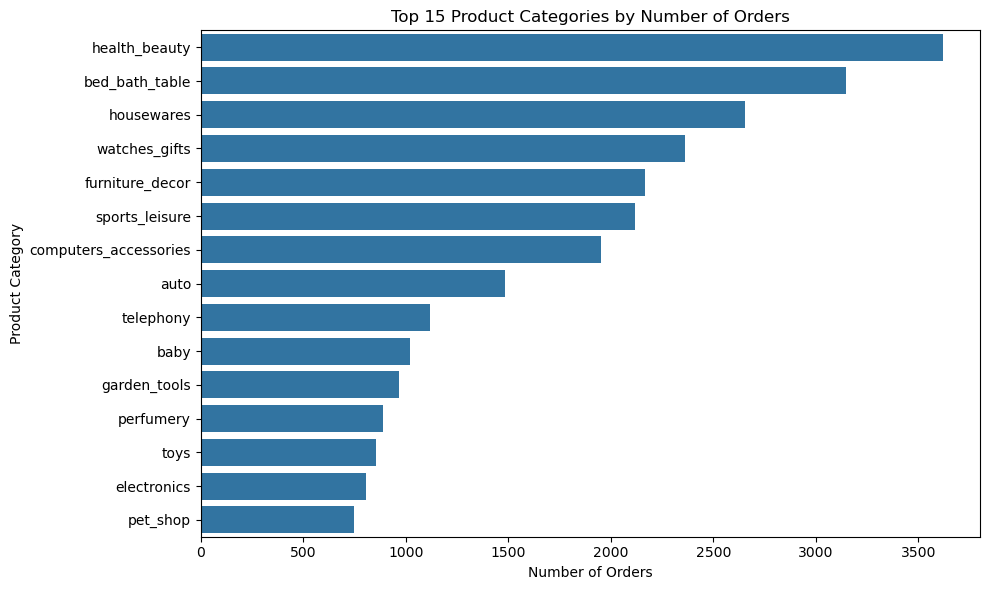

In [27]:
top_categories = (
    df["product_category_name_english"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title("Top 15 Product Categories by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

`Observation:` The distribution of product categories is uneven. The `health_beauty` category has the highest number of observations, followed by `bed_bath_table` and `housewares`. Several other categories such as `watches_gifts`, `furniture_decor`, and `sports_leisure` also have substantial representation. This indicates that the dataset contains more observations from certain product categories than others.

In [28]:
print("Number of unique customer cities:", df["customer_city"].nunique())
print("Number of unique seller cities:", df["seller_city"].nunique())

Number of unique customer cities: 2521
Number of unique seller cities: 464


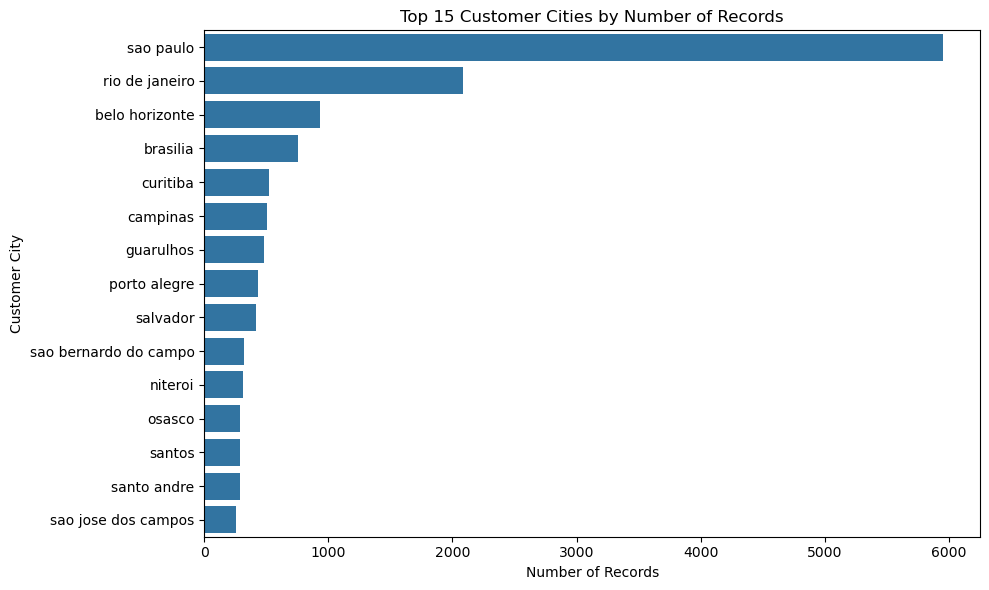

In [29]:
top_customer_cities = df["customer_city"].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_customer_cities.values,
    y=top_customer_cities.index
)

plt.title("Top 15 Customer Cities by Number of Records")
plt.xlabel("Number of Records")
plt.ylabel("Customer City")
plt.tight_layout()
plt.show()

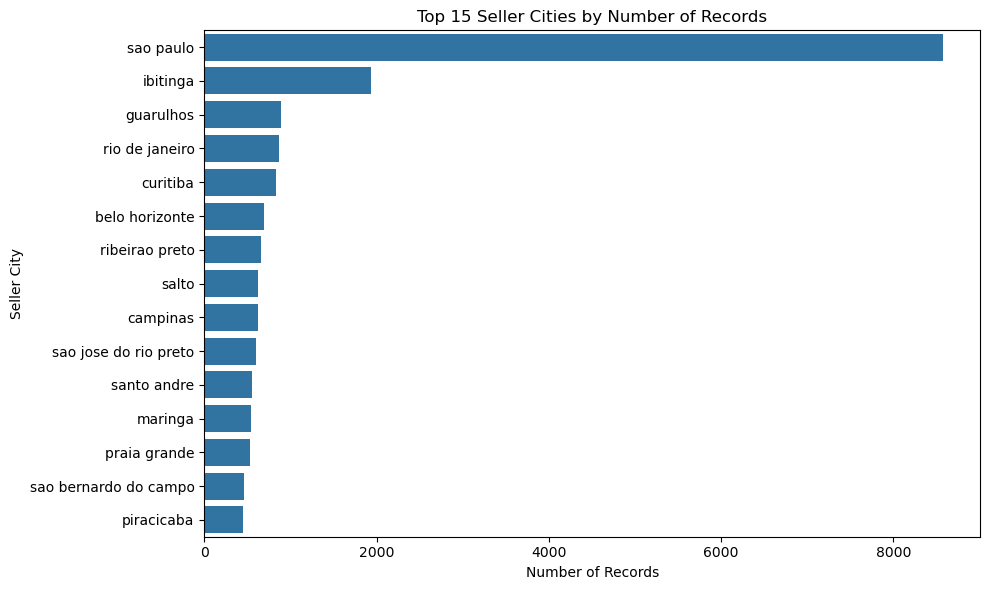

In [30]:
top_seller_cities = df["seller_city"].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_seller_cities.values,
    y=top_seller_cities.index
)

plt.title("Top 15 Seller Cities by Number of Records")
plt.xlabel("Number of Records")
plt.ylabel("Seller City")
plt.tight_layout()
plt.show()

### Observation:

`customer_city` - The customer city distribution is highly concentrated in a small number of cities. São Paulo has substantially more observations than the other cities, followed by Rio de Janeiro and Belo Horizonte. Although the dataset contains 2,521 unique customer cities, most observations are concentrated among a relatively small number of cities.

`seller_city` - The seller city distribution is highly concentrated, with São Paulo accounting for a very large proportion of observations. Ibitinga, Guarulhos, Rio de Janeiro, and Curitiba are among the next most frequent seller cities. Despite having 464 unique seller cities, the majority of records are concentrated in a relatively small number of cities.

In [31]:
df["order_purchase_timestamp"] = pd.to_datetime(
    df["order_purchase_timestamp"],
    errors="coerce"
)

print("Earliest purchase:", df["order_purchase_timestamp"].min())
print("Latest purchase:", df["order_purchase_timestamp"].max())
print("Missing timestamps:", df["order_purchase_timestamp"].isna().sum())

Earliest purchase: 2018-04-17 00:12:44
Latest purchase: 2018-09-03 09:06:57
Missing timestamps: 0


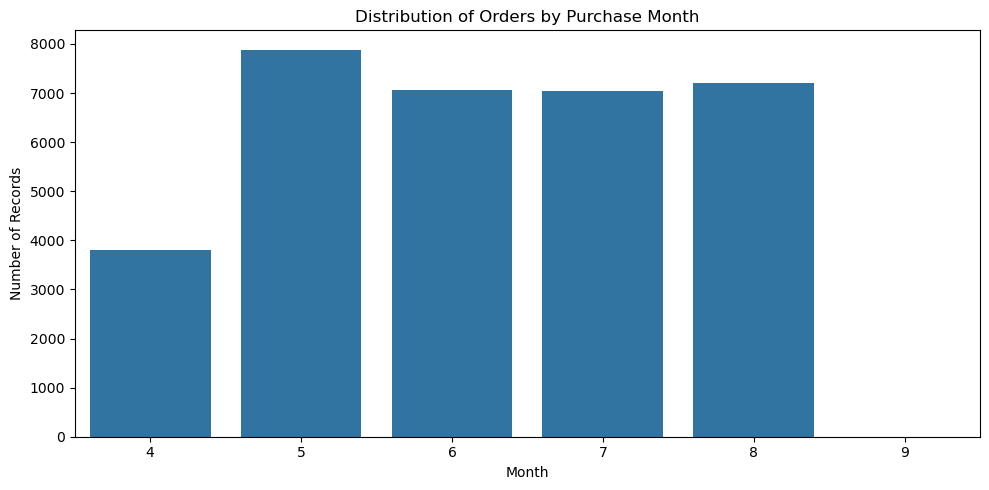

In [32]:
df["purchase_month"] = df["order_purchase_timestamp"].dt.month

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="purchase_month",
    order=sorted(df["purchase_month"].dropna().unique())
)

plt.title("Distribution of Orders by Purchase Month")
plt.xlabel("Month")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

In [33]:
comment_features = [
    "review_comment_title",
    "review_comment_message"
]

for feature in comment_features:
    print(f"\n{feature}")
    print("Missing:", df[feature].isna().sum())
    print("Non-missing:", df[feature].notna().sum())
    print("Unique values:", df[feature].nunique())


review_comment_title
Missing: 23905
Non-missing: 9090
Unique values: 3253

review_comment_message
Missing: 23406
Non-missing: 9589
Unique values: 7412


In [39]:
df["title_length"] = (
    df["review_comment_title"]
    .fillna("")
    .str.len()
)

df["message_length"] = (
    df["review_comment_message"]
    .fillna("")
    .str.len()
)

print("Comment length features created.")

Comment length features created.


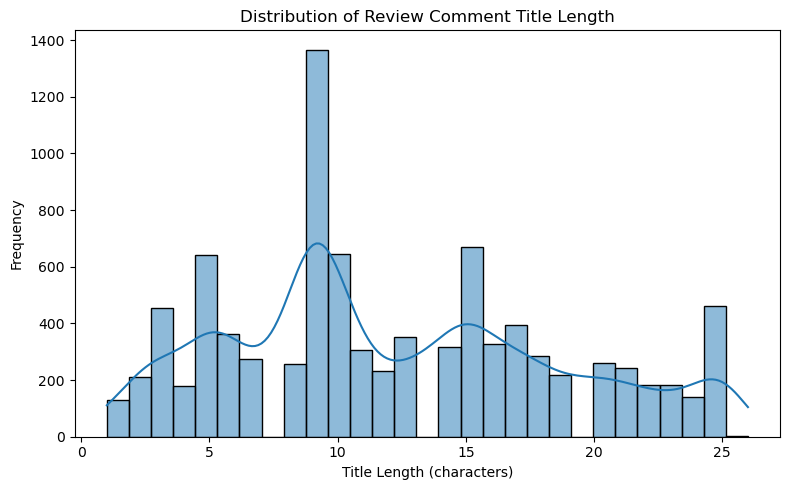

In [40]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df[df["title_length"] > 0],
    x="title_length",
    kde=True
)

plt.title("Distribution of Review Comment Title Length")
plt.xlabel("Title Length (characters)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

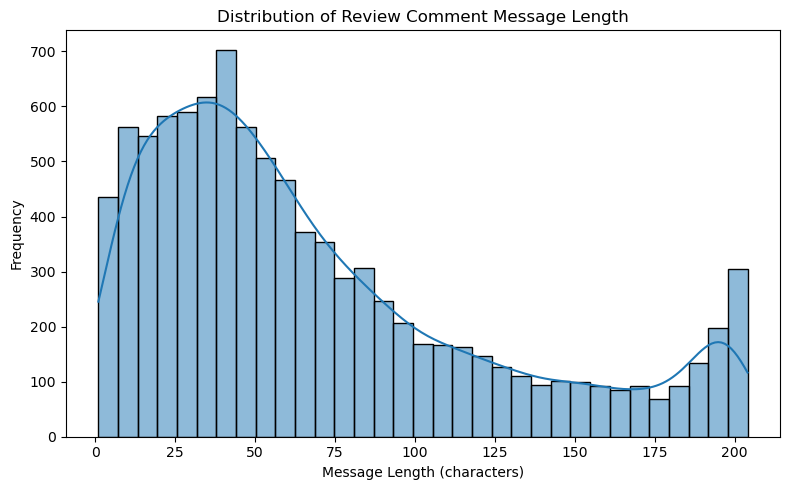

In [41]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df[df["message_length"] > 0],
    x="message_length",
    kde=True
)

plt.title("Distribution of Review Comment Message Length")
plt.xlabel("Message Length (characters)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Observaion

- `review_comment_title_length` - Review comment titles are generally short, with most non-empty titles having fewer than 20 characters. The distribution shows several peaks rather than a single dominant length, indicating variation in how customers provide short review titles.

- `review_comment_message_length` - Review comment messages have a wider range of lengths than review titles. Most non-empty messages are relatively short, with many observations concentrated below approximately 100 characters, while a smaller number of messages are considerably longer. This indicates substantial variation in the amount of text provided by customers.

## 3. Data Cleaning

In [42]:
df_clean = df.copy()
print("Original shape:", df_clean.shape)

Original shape: (32995, 20)


In [43]:
duplicate_count = df_clean.duplicated().sum()
print("Duplicate rows:", duplicate_count)

df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df_clean.shape)

Duplicate rows: 2951
Shape after removing duplicates: (30044, 20)


#### Observation: 
Exact duplicate records were identified and removed because they contain identical information across all columns. Repeated `order_id` values were not removed because multiple records can legitimately belong to the same order.

In [44]:
missing_summary = (
    df_clean.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_percentage = (
    df_clean.isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_table = pd.DataFrame({
    "Missing Count": missing_summary,
    "Missing Percentage": missing_percentage.round(2)
})

missing_table[missing_table["Missing Count"] > 0]

,Missing Count,Missing Percentage
review_comment_title,21909,72.92
review_comment_message,21517,71.62
review_score,8738,29.08


Since `review_score` is the target variable, records with missing target values cannot be used for supervised classification. These records are therefore removed rather than imputed, because assigning an artificial review score could introduce bias into the model.

In [46]:
df_clean = df_clean.dropna(subset=["review_score"]).reset_index(drop=True)

print("Shape after removing missing target values:", df_clean.shape)
print("Missing review_score:", df_clean["review_score"].isna().sum())

Shape after removing missing target values: (21306, 20)
Missing review_score: 0


The review comment title and message contain information generated as part of the customer's review. Since `review_score` is the prediction target, using these post-review text fields would introduce information leakage. They also contain a high proportion of missing values. Therefore, both columns are excluded from the classification features.

In [47]:
df_clean = df_clean.drop(
    columns=["review_comment_title", "review_comment_message"]
)

print("Columns after removing review comment fields:")
print(df_clean.columns.tolist())

Columns after removing review comment fields:
['order_id', 'customer_id', 'order_purchase_timestamp', 'order_status', 'customer_city', 'customer_state', 'product_id', 'seller_id', 'price', 'freight_value', 'review_score', 'seller_city', 'seller_state', 'product_weight_g', 'product_category_name_english', 'purchase_month', 'title_length', 'message_length']


In [48]:
df_clean = df_clean.drop(
    columns=["purchase_month", "title_length", "message_length"],
    errors="ignore"
)

print(df_clean.columns.tolist())

['order_id', 'customer_id', 'order_purchase_timestamp', 'order_status', 'customer_city', 'customer_state', 'product_id', 'seller_id', 'price', 'freight_value', 'review_score', 'seller_city', 'seller_state', 'product_weight_g', 'product_category_name_english']


In [49]:
missing_after_cleaning = df_clean.isnull().sum()

print(
    missing_after_cleaning[
        missing_after_cleaning > 0
    ]
)

Series([], dtype: int64)


In [50]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21306 entries, 0 to 21305
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       21306 non-null  object        
 1   customer_id                    21306 non-null  object        
 2   order_purchase_timestamp       21306 non-null  datetime64[ns]
 3   order_status                   21306 non-null  object        
 4   customer_city                  21306 non-null  object        
 5   customer_state                 21306 non-null  object        
 6   product_id                     21306 non-null  object        
 7   seller_id                      21306 non-null  object        
 8   price                          21306 non-null  float64       
 9   freight_value                  21306 non-null  float64       
 10  review_score                   21306 non-null  float64       
 11  seller_city    

### Outlier detection

In [51]:
numerical_features = [
    "price",
    "freight_value",
    "product_weight_g"
]

outlier_summary = []

for feature in numerical_features:
    Q1 = df_clean[feature].quantile(0.25)
    Q3 = df_clean[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (df_clean[feature] < lower_bound) |
        (df_clean[feature] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outliers,
        "Outlier %": round(outliers / len(df_clean) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,price,42.1125,139.00,96.8875,-103.21875,284.33125,1647,7.73
1,freight_value,12.8300,23.05,10.2200,-2.50000,38.38000,2111,9.91
2,product_weight_g,275.0000,1700.00,1425.0000,-1862.50000,3837.50000,2858,13.41


### Outlier Analysis and Treatment

The IQR method identified statistical outliers in the numerical features: 7.73% in `price`, 9.91% in `freight_value`, and 13.41% in `product_weight_g`. 

However, these observations were not automatically removed because extreme values can represent legitimate products, shipping costs, or product weights rather than data-entry errors. The distributions also show strong right-skewness. 

Therefore, the identified outliers are retained. Their influence will instead be addressed during feature preprocessing, where appropriate transformations and scaling can reduce the effect of extreme values without discarding potentially useful observations.

In [52]:
print("Price <= 0:", (df_clean["price"] <= 0).sum())
print("Freight value < 0:", (df_clean["freight_value"] < 0).sum())
print("Product weight <= 0:", (df_clean["product_weight_g"] <= 0).sum())

Price <= 0: 0
Freight value < 0: 0
Product weight <= 0: 5


In [53]:
print("Review scores:")
print(df_clean["review_score"].value_counts().sort_index())

Review scores:
review_score
1.0    1949
2.0    3610
3.0    5527
4.0    5016
5.0    5204
Name: count, dtype: int64


### Handling Invalid Numerical Values

Five records contain non-positive values for `product_weight_g`, which are not physically meaningful for a product weight. These values are treated as missing and will be imputed using the median product weight. Median imputation is appropriate because the product-weight distribution is strongly right-skewed and the median is less sensitive to extreme values.

In [54]:
# Treat non-positive product weights as missing
df_clean.loc[
    df_clean["product_weight_g"] <= 0,
    "product_weight_g"
] = np.nan

print(
    "Invalid product weights replaced with NaN:",
    df_clean["product_weight_g"].isna().sum()
)

Invalid product weights replaced with NaN: 5


## 4. Feature Engineering

In [55]:
df_clean["total_cost"] = (
    df_clean["price"] + df_clean["freight_value"]
)

In [56]:
df_clean["freight_ratio"] = (
    df_clean["freight_value"] / df_clean["price"]
)

In [57]:
df_clean["purchase_hour"] = (
    df_clean["order_purchase_timestamp"].dt.hour
)

df_clean["purchase_dayofweek"] = (
    df_clean["order_purchase_timestamp"].dt.dayofweek
)

df_clean["purchase_month"] = (
    df_clean["order_purchase_timestamp"].dt.month
)

In [58]:
df_clean[
    [
        "price",
        "freight_value",
        "total_cost",
        "freight_ratio",
        "purchase_hour",
        "purchase_dayofweek",
        "purchase_month"
    ]
].head()

,price,freight_value,total_cost,freight_ratio,purchase_hour,purchase_dayofweek,purchase_month
0,74.0,23.32,97.32,0.315135,17,1,7
1,639.0,11.34,650.34,0.017746,9,2,4
2,109.9,13.21,123.11,0.120200,12,6,4
3,159.8,16.42,176.22,0.102753,11,2,8
4,249.9,34.23,284.13,0.136975,16,0,7


In [59]:
df_clean[
    [
        "total_cost",
        "freight_ratio",
        "purchase_hour",
        "purchase_dayofweek",
        "purchase_month"
    ]
].describe()

,total_cost,freight_ratio,purchase_hour,purchase_dayofweek,purchase_month
count,21306.000000,21306.000000,21306.000000,21306.000000,21306.000000
mean,148.217034,0.312619,14.798507,2.708157,6.196424
std,204.371906,0.338424,5.264726,1.960719,1.331280
min,10.330000,0.000000,0.000000,0.000000,4.000000
25%,57.872500,0.128198,11.000000,1.000000,5.000000
50%,98.515000,0.226205,15.000000,3.000000,6.000000
75%,163.440000,0.391732,19.000000,4.000000,7.000000
max,4513.320000,21.447059,23.000000,6.000000,8.000000


### Feature Engineering - summary

Several meaningful features were engineered to improve the representation of customer orders:

1. **`total_cost`** = `price + freight_value`: represents the combined monetary cost of the product and shipping.

2. **`freight_ratio`** = `freight_value / price`: captures the relative burden of shipping cost compared with product price.

3. **`purchase_hour`**: captures the time of day at which the order was placed.

4. **`purchase_dayofweek`**: captures potential differences between weekday and weekend purchasing behavior.

5. **`purchase_month`**: captures potential temporal or seasonal variation in purchasing patterns.

These features provide information that is not directly represented by the original individual variables.

## 5. Feature Selection

The identifier columns `order_id`, `customer_id`, `product_id`, and `seller_id` are excluded because they are unique identifiers and do not represent meaningful predictive characteristics.

The original timestamp column `order_purchase_timestamp` is excluded after extracting useful temporal features such as purchase hour, day of week, and month.

The high-cardinality `customer_city` and `seller_city` variables are excluded to avoid unnecessarily large sparse feature representations from one-hot encoding. State-level geographical features are retained as lower-cardinality alternatives.

The review comment fields were previously excluded because they contain post-review information and could introduce target leakage when predicting `review_score`.

In [61]:
feature_columns = [
    "price",
    "freight_value",
    "product_weight_g",
    "total_cost",
    "freight_ratio",
    "purchase_hour",
    "purchase_dayofweek",
    "purchase_month",
    "order_status",
    "customer_state",
    "seller_state",
    "product_category_name_english"
]

X = df_clean[feature_columns].copy()
y = df_clean["review_score"].astype(int).copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Feature matrix shape: (21306, 12)
Target shape: (21306,)

Features:
['price', 'freight_value', 'product_weight_g', 'total_cost', 'freight_ratio', 'purchase_hour', 'purchase_dayofweek', 'purchase_month', 'order_status', 'customer_state', 'seller_state', 'product_category_name_english']


In [62]:
print("\nTarget distribution:")
print(y.value_counts().sort_index())


Target distribution:
review_score
1    1949
2    3610
3    5527
4    5016
5    5204
Name: count, dtype: int64


## 6. Train-Test Split

The dataset is divided into training and testing sets using an 80:20 split. Stratified sampling is used to preserve the class distribution of `review_score` in both sets. A fixed `random_state=42` is used to ensure reproducibility.

All preprocessing transformations will be fitted exclusively on the training data and then applied to the test data to prevent data leakage.

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (17044, 12)
X_test : (4262, 12)
y_train: (17044,)
y_test : (4262,)


In [64]:
split_distribution = pd.DataFrame({
    "Full Dataset": y.value_counts(normalize=True).sort_index() * 100,
    "Training Set": y_train.value_counts(normalize=True).sort_index() * 100,
    "Test Set": y_test.value_counts(normalize=True).sort_index() * 100
})

split_distribution.round(2)

,Full Dataset,Training Set,Test Set
review_score,,,
1,9.15,9.15,9.15
2,16.94,16.94,16.94
3,25.94,25.94,25.95
4,23.54,23.54,23.53
5,24.43,24.43,24.43


## 7. Data Preprocessing

Numerical and categorical features require different preprocessing strategies. Numerical variables will be imputed where necessary and scaled, while categorical variables will be one-hot encoded. All preprocessing steps will be fitted only on the training data to prevent data leakage.

In [66]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    "price",
    "freight_value",
    "product_weight_g",
    "total_cost",
    "freight_ratio",
    "purchase_hour",
    "purchase_dayofweek",
    "purchase_month"
]

categorical_features = [
    "order_status",
    "customer_state",
    "seller_state",
    "product_category_name_english"
]

In [67]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [68]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

In [69]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [71]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape :", X_test_processed.shape)

Processed X_train shape: (17044, 125)
Processed X_test shape : (4262, 125)


In [74]:
print("NaNs in X_train_processed:", np.isnan(X_train_processed).sum())
print("NaNs in X_test_processed :", np.isnan(X_test_processed).sum())

print("Infinite values in X_train_processed:",
      np.isinf(X_train_processed).sum())
print("Infinite values in X_test_processed:",
      np.isinf(X_test_processed).sum())

NaNs in X_train_processed: 0
NaNs in X_test_processed : 0
Infinite values in X_train_processed: 0
Infinite values in X_test_processed: 0


In [75]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))

for i, feature in enumerate(feature_names, start=1):
    print(i, feature)

Number of processed features: 125
1 num__price
2 num__freight_value
3 num__product_weight_g
4 num__total_cost
5 num__freight_ratio
6 num__purchase_hour
7 num__purchase_dayofweek
8 num__purchase_month
9 cat__order_status_canceled
10 cat__order_status_delivered
11 cat__order_status_invoiced
12 cat__order_status_processing
13 cat__order_status_shipped
14 cat__customer_state_AC
15 cat__customer_state_AL
16 cat__customer_state_AM
17 cat__customer_state_AP
18 cat__customer_state_BA
19 cat__customer_state_CE
20 cat__customer_state_DF
21 cat__customer_state_ES
22 cat__customer_state_GO
23 cat__customer_state_MA
24 cat__customer_state_MG
25 cat__customer_state_MS
26 cat__customer_state_MT
27 cat__customer_state_PA
28 cat__customer_state_PB
29 cat__customer_state_PE
30 cat__customer_state_PI
31 cat__customer_state_PR
32 cat__customer_state_RJ
33 cat__customer_state_RN
34 cat__customer_state_RO
35 cat__customer_state_RR
36 cat__customer_state_RS
37 cat__customer_state_SC
38 cat__customer_state_SE

### Final Preprocessing

The dataset was divided into training and testing sets using an 80:20 stratified split with random_state=42. Numerical features were median-imputed and standardized using StandardScaler, while categorical features were imputed using the most frequent value and one-hot encoded. The preprocessing transformations were fitted only on the training data and subsequently applied to the test data to prevent data leakage. The resulting feature matrix contains 125 features.

## Saving Prepared Classification Data

The final train-test split and preprocessing results are saved so that all
classification algorithms use the same data representation.

This ensures a fair comparison between Logistic Regression, KNN,
Gaussian Naive Bayes, Decision Tree, and SVC without repeating the
cleaning and preprocessing steps in each notebook.

In [77]:
np.savez(
    "classification_data.npz",
    X_train=X_train_processed,
    X_test=X_test_processed,
    y_train=y_train.to_numpy(),
    y_test=y_test.to_numpy()
)

pd.Series(feature_names).to_csv(
    "classification_feature_names.csv",
    index=False,
    header=False
)

print("Classification data saved successfully.")
print("X_train:", X_train_processed.shape)
print("X_test :", X_test_processed.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Classification data saved successfully.
X_train: (17044, 125)
X_test : (4262, 125)
y_train: (17044,)
y_test : (4262,)
